<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


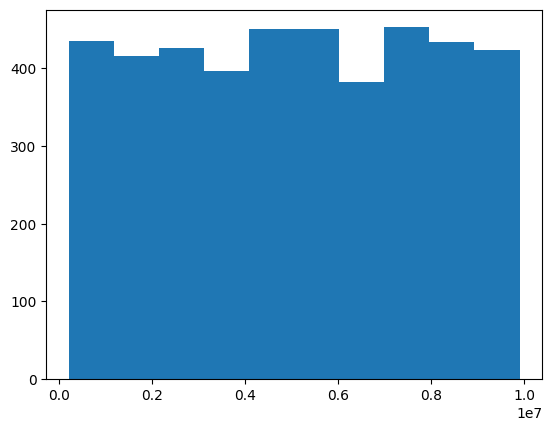

0.9765807962529274

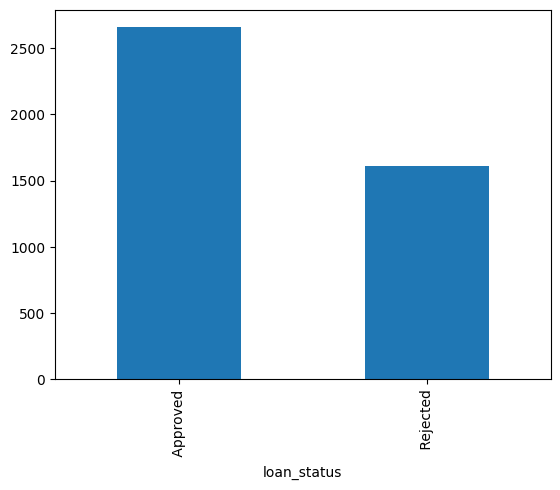

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("loan_approval_dataset.csv")
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()
df.head()
df.shape
df.isnull().sum()
df.info()
plt.hist(df["income_annum"])
plt.show()
df["loan_status"].value_counts().plot(kind="bar")

# Map 'loan_status' to numerical values for the target variable 'y'
# Strip whitespace from the loan_status values before mapping
y = df['loan_status'].str.strip().map({'Approved': 0, 'Rejected': 1})

# Drop the original 'loan_status' column from the DataFrame to create features 'X'
X_df = df.drop('loan_status', axis=1)

# Convert remaining categorical features in X_df to numerical using one-hot encoding
X = pd.get_dummies(X_df, columns=['education', 'self_employed'], drop_first=True)

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
model = RandomForestClassifier()

model.fit(X_train,y_train)
# Make predictions on the test set
prediction = model.predict(X_test)
accuracy_score(y_test,prediction)
# model.predict(new_data) # Commented out as 'new_data' is not defined

